## Portfolio archive and evaluation note

This notebook is retained as part of the original MRI denoising experiment suite. Saved cells and outputs are included so the development work can be reviewed without rerunning long GPU training jobs.

> **Evaluation limitation:** In the supplied workflow, several experiments use the same image directory for both training and validation. The stored metrics are therefore historical development results, not independently reproduced estimates from a held-out validation set. A reliable rerun should use patient-level train, validation, and test splits.

The code was developed in Google Colab and contains hard-coded paths under `/content/drive/MyDrive/Final RI/`. Update those paths before running it with your own dataset.


In [ ]:
# ===========================
#  All Noise Combined
# ===========================
import os, cv2, numpy as np, glob, random, zipfile, pandas as pd
from tqdm import tqdm
from google.colab import drive

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Unzip glioma.zip if needed ---
zip_path = "/content/drive/MyDrive/Final RI/glioma.zip"
extract_path = "/content/drive/MyDrive/Final RI/glioma"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Extracted glioma.zip to:", extract_path)
else:
    print(" glioma/ already exists. Skipping extraction.")

# --- 3. Set Paths ---
CLEAN_DIR = extract_path
COMBINED_NOISY_DIR = "/content/drive/MyDrive/Final RI/noisy_glioma/all_combined"
os.makedirs(COMBINED_NOISY_DIR, exist_ok=True)

# ---  4. Reproducibility ---
random.seed(42)
np.random.seed(42)

# --- 5. Define Noise Functions ---
def safe_clip(img):
    return np.clip(img, 1e-6, 1.0)

def add_rician_noise(img, sigma=0.05):
    noise_real = np.random.normal(0, sigma, img.shape)
    noise_imag = np.random.normal(0, sigma, img.shape)
    return safe_clip(np.sqrt((img + noise_real)**2 + noise_imag**2))

def add_speckle_noise(img, var=0.04):
    noise = np.random.randn(*img.shape)
    return safe_clip(img + img * noise * var)

def add_gaussian_noise(img, mean=0, std=0.02):
    noise = np.random.normal(mean, std, img.shape)
    return safe_clip(img + noise)

def add_poisson_noise(img):
    vals = len(np.unique(img))
    vals = 2 ** np.ceil(np.log2(vals))
    return safe_clip(np.random.poisson(img * vals) / float(vals))

def add_multiplicative_noise(img, alpha=0.4):
    noise = np.random.normal(1.0, alpha, img.shape)
    return safe_clip(img * noise)

def add_periodic_artifact(img, freq=8, amplitude=0.1):
    rows, cols = img.shape
    x = np.arange(cols)
    y = np.arange(rows)
    xv, yv = np.meshgrid(x, y)
    sinusoid = amplitude * np.sin(2 * np.pi * freq * xv / cols)
    return safe_clip(img + sinusoid)

# --- 6. Apply All Noises ---
def apply_all_noise(img):
    noise_log = []

    img = add_gaussian_noise(img, std=0.02)
    noise_log.append("Gaussian(std=0.02)")

    img = add_rician_noise(img, sigma=0.05)
    noise_log.append("Rician(sigma=0.05)")

    img = add_speckle_noise(img, var=0.05)
    noise_log.append("Speckle(var=0.05)")

    img = add_multiplicative_noise(img, alpha=0.3)
    noise_log.append("Multiplicative(alpha=0.3)")

    img = add_poisson_noise(img)
    noise_log.append("Poisson")

    img = add_periodic_artifact(img, freq=6, amplitude=0.05)
    noise_log.append("Periodic(freq=6,amp=0.05)")

    return safe_clip(img), noise_log

# --- 7. Process All Images with All Noise ---
image_paths = sorted(glob.glob(os.path.join(CLEAN_DIR, "*.*")))
log_data = []

print(f" Found {len(image_paths)} clean images to process (all-noise combined)")

for img_path in tqdm(image_paths, desc=" Applying All Noise"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f" Skipping unreadable file: {img_path}")
        continue

    img = cv2.resize(img, (256, 256)).astype(np.float32) / 255.0
    img_noisy, noise_types = apply_all_noise(img)

    # --- Optional Extra Periodic Artifact ---
    if random.random() < 0.3:
        f = random.randint(5, 10)
        a = round(random.uniform(0.06, 0.08), 3)
        img_noisy = add_periodic_artifact(img_noisy, freq=f, amplitude=a)
        noise_types.append(f"ExtraPeriodic(freq={f},amp={a})")

    # --- Save Noisy Image ---
    out_path = os.path.join(COMBINED_NOISY_DIR, os.path.basename(img_path))
    img_save = (img_noisy * 255).astype(np.uint8)
    cv2.imwrite(out_path, img_save)

    # --- Log Entry ---
    log_data.append({
        "filename": os.path.basename(img_path),
        "noise_types": " + ".join(noise_types)
    })

# --- 8. Save CSV Log ---
log_df = pd.DataFrame(log_data)
csv_path = os.path.join(COMBINED_NOISY_DIR, "noise_log_all_combined.csv")
log_df.to_csv(csv_path, index=False)

print(f" All-noise-combined images saved to: {COMBINED_NOISY_DIR}")
print(f" Noise log saved to: {csv_path}")


Mounted at /content/drive
✅ Extracted glioma.zip to: /content/drive/MyDrive/Final RI/glioma
🔍 Found 1297 clean images to process (all-noise combined)


🔧 Applying All Noise: 100%|██████████| 1297/1297 [06:26<00:00,  3.36it/s]


✅ All-noise-combined images saved to: /content/drive/MyDrive/Final RI/noisy_glioma/all_combined
📄 Noise log saved to: /content/drive/MyDrive/Final RI/noisy_glioma/all_combined/noise_log_all_combined.csv


In [ ]:
# ===========================
#  Cell 2: MRI Dataset Loader (Stage 1 — Clean Loader, Fixed Mismatch)
# ===========================
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import os, cv2, numpy as np
from glob import glob

# ---  Normalize & Transform ---
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [C, H, W] float32 in [0, 1]
])

# ---  Robust Dataset Class ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        # Collect only image files
        noisy_all = sorted(glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob(os.path.join(clean_dir, "*.*")))

        # Build dicts of filename → path
        noisy_dict = {os.path.basename(p): p for p in noisy_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}
        clean_dict = {os.path.basename(p): p for p in clean_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

        # Match only common filenames
        common_filenames = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        assert common_filenames, " No matching image files found between noisy and clean dirs."

        # Build matched path lists
        self.noisy_paths = [noisy_dict[f] for f in common_filenames]
        self.clean_paths = [clean_dict[f] for f in common_filenames]
        self.transform = transform

        print(f"[INFO]  Matched {len(self.noisy_paths)} image pairs.")

    def __len__(self):
        return len(self.noisy_paths)

    def __getitem__(self, idx):
        noisy_path = self.noisy_paths[idx]
        clean_path = self.clean_paths[idx]

        noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)

        if noisy is None or clean is None:
            raise ValueError(f"Invalid image: {noisy_path} or {clean_path}")

        # Resize and normalize to [0, 1]
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0

        # Apply transform
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)

        return noisy, clean

# ---  Set Paths for Training/Validation (All Combined Noise)
train_noisy_dir = "/content/drive/MyDrive/Final RI/noisy_glioma/all_combined"
train_clean_dir = "/content/drive/MyDrive/Final RI/glioma"
val_noisy_dir   = "/content/drive/MyDrive/Final RI/noisy_glioma/all_combined"
val_clean_dir   = "/content/drive/MyDrive/Final RI/glioma"

# ---  Create Dataset Objects
train_dataset = MRIDenoisingDataset(train_noisy_dir, train_clean_dir, transform)
val_dataset   = MRIDenoisingDataset(val_noisy_dir, val_clean_dir, transform)

print(f"[INFO]  Loaded {len(train_dataset)} training images")
print(f"[INFO]  Loaded {len(val_dataset)} validation images")


[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Loaded 1297 training images
[INFO] ✅ Loaded 1297 validation images


In [ ]:
# ===========================
#  Cell 3: Generator (Stage 1 – VAE + U-Net only)
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---  Conv Block with InstanceNorm ---
def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.InstanceNorm2d(out_channels),
        nn.LeakyReLU(0.2, inplace=True)
    )

# ---  VAE + U-Net Generator (No MoE, No Transformer)
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
        super(UNetGenerator, self).__init__()

        # --- Encoder ---
        self.enc1 = conv_block(in_channels, 64)       # -> [B, 64, 256, 256]
        self.enc2 = conv_block(64, 128)               # -> [B, 128, 128, 128]
        self.enc3 = conv_block(128, 256)              # -> [B, 256, 64, 64]
        self.enc4 = conv_block(256, 512)              # -> [B, 512, 32, 32]
        self.pool = nn.MaxPool2d(2)

        # --- VAE Latent Bottleneck ---
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_decoder = nn.Linear(latent_dim, 512 * 16 * 16)
        self.unflatten = nn.Unflatten(1, (512, 16, 16))

        # --- Decoder (U-Net with skip connections) ---
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = conv_block(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # --- Encode ---
        e1 = self.enc1(x)                # [B, 64, 256, 256]
        e2 = self.enc2(self.pool(e1))    # [B, 128, 128, 128]
        e3 = self.enc3(self.pool(e2))    # [B, 256, 64, 64]
        e4 = self.enc4(self.pool(e3))    # [B, 512, 32, 32]
        e4_pool = self.pool(e4)          # [B, 512, 16, 16]

        # --- VAE bottleneck ---
        flat = self.flatten(e4_pool)     # [B, 512*16*16]
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)
        z = self.reparameterize(mu, logvar)
        z = self.unflatten(self.fc_decoder(z))        # [B, 512, 16, 16]
        z = F.interpolate(z, size=(32, 32), mode='bilinear', align_corners=False)

        # --- Decode ---
        d1 = self.up1(z)                         # [B, 256, 64, 64]
        d1 = self.dec1(torch.cat([d1, e3], dim=1))

        d2 = self.up2(d1)                        # [B, 128, 128, 128]
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d3 = self.up3(d2)                        # [B, 64, 256, 256]
        d3 = self.dec3(torch.cat([d3, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d3))   # [B, 1, 256, 256]
        return out, mu, logvar


In [ ]:
# ===========================
#  Cell 4: DWT + PatchGAN Discriminator (Final for Stage 1 & 2)
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt
import numpy as np

# ---  DWT Layer: Extracts LL, LH, HL, HH from each channel ---
class DWT_2D(nn.Module):
    def __init__(self, wave='haar'):
        super(DWT_2D, self).__init__()
        self.wave = wave

    def forward(self, x):
        B, C, H, W = x.shape
        dwt_output = []
        for b in range(B):
            channels = []
            for c in range(C):
                arr = x[b, c].detach().cpu().numpy()
                LL, (LH, HL, HH) = pywt.dwt2(arr, self.wave)
                channels.extend([LL, LH, HL, HH])
            stacked = np.stack(channels)
            dwt_output.append(torch.from_numpy(stacked).float())
        return torch.stack(dwt_output).to(x.device)

# ---  PatchGAN Discriminator using DWT features ---
class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super(Discriminator, self).__init__()
        self.dwt = DWT_2D()

        self.net = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # 4 = LL + LH + HL + HH
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)  # Patch output
        )

    def forward(self, x):
        with torch.no_grad():  # Only use DWT as a feature pre-processor
            x = self.dwt(x)    # [B, 1, H, W] → [B, 4, H/2, W/2]
        return self.net(x)


In [ ]:
# ===========================
#  Cell 5: Loss Functions (Stage 1 — L1 + SSIM + GAN + Clipped KL)
# ===========================

!pip install pytorch-ssim

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_ssim  # pip install pytorch-ssim

# ---  Loss Functions ---
l1_criterion = nn.L1Loss()
ssim_criterion = pytorch_ssim.SSIM(window_size=11)
bce_criterion = nn.BCEWithLogitsLoss()

# ---  Clipped KL Divergence Loss for VAE
def kl_divergence(mu, logvar):
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return torch.clamp(kl, max=1000.0)  #  Prevent KL explosion

# ---  Discriminator Loss ---
def get_discriminator_loss(D, real_imgs, fake_imgs):
    real_preds = D(real_imgs)
    fake_preds = D(fake_imgs.detach())

    real_labels = torch.ones_like(real_preds)
    fake_labels = torch.zeros_like(fake_preds)

    real_loss = bce_criterion(real_preds, real_labels)
    fake_loss = bce_criterion(fake_preds, fake_labels)

    return 0.5 * (real_loss + fake_loss)

# ---  Generator Loss (L1 + SSIM + GAN + KL)
def get_generator_loss(D, fake_imgs, real_imgs, mu, logvar):
    pred_fake = D(fake_imgs)
    adv_loss  = bce_criterion(pred_fake, torch.ones_like(pred_fake))  # GAN
    l1_loss   = l1_criterion(fake_imgs, real_imgs)                    # L1
    ssim_loss = 1 - ssim_criterion(fake_imgs, real_imgs)              # SSIM
    kl_loss   = kl_divergence(mu, logvar)                             # KL (clipped)

    total_loss = 5.0 * l1_loss + 10.0 * ssim_loss + 0.5 * adv_loss + 0.01 * kl_loss

    return total_loss, {
        "L1": l1_loss.item(),
        "SSIM": 1 - ssim_loss.item(),  # return SSIM score (not loss)
        "Adv": adv_loss.item(),
        "KL": kl_loss.item()
    }


  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-ssim: filename=pytorch_ssim-0.1-py3-none-any.whl size=2006 sha256=25911798a11ca502e3fd462599628b39ba2373dfa7861ee649e9f3c9e9a699e0
  Stored in directory: /root/.cache/pip/wheels/54/a0/11/99f86224e71729ed9ef0c4ffe1b795807ad5f44bde19bc66f9
Successfully built pytorch-ssim


In [ ]:
# ================================
#  Patch SSIM padding issue + move window to correct device
# ================================
import pytorch_ssim
import torch.nn.functional as F

def fixed_ssim(img1, img2, window, window_size, channel, size_average=True):
    padding = int(window_size // 2)

    #  Move window to same device as input
    window = window.to(img1.device)

    mu1 = F.conv2d(img1, window, padding=padding, groups=channel)
    mu2 = F.conv2d(img2, window, padding=padding, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=padding, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=padding, groups=channel) - mu2_sq
    sigma12  = F.conv2d(img1 * img2, window, padding=padding, groups=channel) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    return ssim_map.mean() if size_average else ssim_map.mean(1).mean(1).mean(1)

#  Patch in place
pytorch_ssim._ssim = fixed_ssim


In [ ]:
# ===========================
#  Cell 6: Safe Training Loop with KL Clipping + NaN/Inf Guard
# ===========================

import os
import torch
from torch.utils.data import DataLoader
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
from tqdm import tqdm

# --- Hyperparameters ---
BATCH_SIZE = 4
KL_WEIGHT = 1000.0  # Fixed KL weight

# --- Dataloaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)

# --- Models ---
G = UNetGenerator().cuda()
D = Discriminator().cuda()

# --- Optimizers ---
g_optimizer = torch.optim.Adam(G.parameters(), lr=1e-4)
d_optimizer = torch.optim.Adam(D.parameters(), lr=1e-5)

# --- Checkpoint path ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints"
os.makedirs(SAVE_PATH, exist_ok=True)
BEST_SSIM = 0.0

def train(epochs):
    global BEST_SSIM
    for epoch in range(1, epochs + 1):
        G.train()
        D.train()
        running_g_loss = 0.0
        running_d_loss = 0.0

        loop = tqdm(train_loader, desc=f" Epoch [{epoch}/{epochs}]")
        for noisy_imgs, clean_imgs in loop:
            noisy_imgs = noisy_imgs.cuda(non_blocking=True)
            clean_imgs = clean_imgs.cuda(non_blocking=True)

            # --- Train Discriminator ---
            D.zero_grad()
            fake_imgs, _, _ = G(noisy_imgs)
            d_loss = get_discriminator_loss(D, clean_imgs, fake_imgs)
            # NaN/Inf safe
            d_loss = torch.where(torch.isnan(d_loss) | torch.isinf(d_loss), torch.zeros_like(d_loss), d_loss)
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), 1.0)
            d_optimizer.step()

            # --- Train Generator ---
            G.zero_grad()
            fake_imgs, mu, logvar = G(noisy_imgs)
            g_loss, g_loss_dict = get_generator_loss(D, fake_imgs, clean_imgs, mu, logvar)

            # Clip KL inside dict
            if "KL" in g_loss_dict and g_loss_dict["KL"] > KL_WEIGHT:
                g_loss_dict["KL"] = KL_WEIGHT

            # NaN/Inf safe
            g_loss = torch.where(torch.isnan(g_loss) | torch.isinf(g_loss), torch.zeros_like(g_loss), g_loss)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
            g_optimizer.step()

            running_g_loss += g_loss.item()
            running_d_loss += d_loss.item()

            loop.set_postfix({
                "G_loss": f"{g_loss.item():.4f}",
                "D_loss": f"{d_loss.item():.4f}",
                "KL": f"{g_loss_dict['KL']:.2f}" if "KL" in g_loss_dict else "-",
                "PSNR": "-",
                "SSIM": "-"
            })

        # --- Validation ---
        G.eval()
        total_psnr = 0.0
        total_ssim = 0.0
        valid_batches = 0

        with torch.no_grad():
            for noisy_imgs, clean_imgs in val_loader:
                noisy_imgs = noisy_imgs.cuda()
                clean_imgs = clean_imgs.cuda()
                fake_imgs, _, _ = G(noisy_imgs)

                pred_np = fake_imgs.squeeze().cpu().numpy()
                target_np = clean_imgs.squeeze().cpu().numpy()

                # Replace NaNs
                pred_np = np.nan_to_num(pred_np)
                target_np = np.nan_to_num(target_np)

                try:
                    psnr = compute_psnr(target_np, pred_np, data_range=1.0)
                    ssim = compute_ssim(target_np, pred_np, data_range=1.0)
                    total_psnr += psnr
                    total_ssim += ssim
                    valid_batches += 1
                except:
                    continue

        avg_psnr = total_psnr / valid_batches if valid_batches > 0 else 0.0
        avg_ssim = total_ssim / valid_batches if valid_batches > 0 else 0.0

        print(f"\n Epoch {epoch}/{epochs} Summary:")
        print(f"   Generator Loss:     {running_g_loss / len(train_loader):.4f}")
        print(f"   Discriminator Loss: {running_d_loss / len(train_loader):.4f}")
        print(f"   Validation PSNR:    {avg_psnr:.2f} dB")
        print(f"   Validation SSIM:    {avg_ssim:.4f}")

        # --- Save best generator ---
        if avg_ssim > BEST_SSIM:
            BEST_SSIM = avg_ssim
            best_path = os.path.join(SAVE_PATH, f"best_generator_epoch{epoch}_ssim{avg_ssim:.4f}.pt")
            torch.save(G.state_dict(), best_path)
            print(f" Best generator saved (Epoch {epoch}) — SSIM: {avg_ssim:.4f}")

# --- Train ---
train(epochs=30)


🧪 Epoch [1/30]: 100%|██████████| 325/325 [01:29<00:00,  3.64it/s, G_loss=8.0354, D_loss=0.0135, KL=12.94, PSNR=-, SSIM=-]



✅ Epoch 1/30 Summary:
   Generator Loss:     8.5156
   Discriminator Loss: 0.1289
   Validation PSNR:    7.06 dB
   Validation SSIM:    0.5990
💾 Best generator saved (Epoch 1) — SSIM: 0.5990


🧪 Epoch [2/30]: 100%|██████████| 325/325 [01:19<00:00,  4.07it/s, G_loss=7.9397, D_loss=0.0038, KL=13.20, PSNR=-, SSIM=-]



✅ Epoch 2/30 Summary:
   Generator Loss:     7.4201
   Discriminator Loss: 0.0100
   Validation PSNR:    9.05 dB
   Validation SSIM:    0.6903
💾 Best generator saved (Epoch 2) — SSIM: 0.6903


🧪 Epoch [3/30]: 100%|██████████| 325/325 [01:18<00:00,  4.13it/s, G_loss=8.0851, D_loss=0.0018, KL=12.22, PSNR=-, SSIM=-]


...


✅ Epoch 28/30 Summary:
   Generator Loss:     2.6814
   Discriminator Loss: 0.2468
   Validation PSNR:    31.03 dB
   Validation SSIM:    0.9146


🧪 Epoch [29/30]: 100%|██████████| 325/325 [01:16<00:00,  4.22it/s, G_loss=4.3049, D_loss=0.1202, KL=5.70, PSNR=-, SSIM=-]



✅ Epoch 29/30 Summary:
   Generator Loss:     2.6150
   Discriminator Loss: 0.2663
   Validation PSNR:    31.17 dB
   Validation SSIM:    0.9145


🧪 Epoch [30/30]: 100%|██████████| 325/325 [01:16<00:00,  4.23it/s, G_loss=3.4812, D_loss=0.0538, KL=11.78, PSNR=-, SSIM=-]



✅ Epoch 30/30 Summary:
   Generator Loss:     2.5892
   Discriminator Loss: 0.2521
   Validation PSNR:    31.33 dB
   Validation SSIM:    0.9168
💾 Best generator saved (Epoch 30) — SSIM: 0.9168


In [ ]:
# ===========================
#  Cell 7: Inference + PSNR/SSIM + Save Images (Stage 1 Final Evaluation)
# ===========================

import os
import torch
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import pandas as pd
from tqdm import tqdm
import numpy as np

# ---  Set Paths ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/inference_all_combined"
os.makedirs(OUTPUT_DIR, exist_ok=True)
IMG_SAVE_DIR = os.path.join(OUTPUT_DIR, "images")
os.makedirs(IMG_SAVE_DIR, exist_ok=True)

# ---  Load Best Generator ---
best_model_path = max(glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator: {os.path.basename(best_model_path)}")

# ---  Inference and Save Images ---
metrics = []

with torch.no_grad():
    for i, (noisy_img, clean_img) in enumerate(tqdm(val_loader, desc=" Running Inference")):
        noisy_img = noisy_img.cuda()
        clean_img = clean_img.cuda()
        denoised_img, _, _ = G(noisy_img)

        # Convert to NumPy for metrics
        noisy_np = noisy_img.squeeze().cpu().numpy()
        clean_np = clean_img.squeeze().cpu().numpy()
        denoised_np = denoised_img.squeeze().cpu().numpy()

        # --- Compute Metrics ---
        psnr = compute_psnr(clean_np, denoised_np, data_range=1.0)
        ssim = compute_ssim(clean_np, denoised_np, data_range=1.0)

        metrics.append({
            "index": i,
            "PSNR": psnr,
            "SSIM": ssim
        })

        # --- Save Image Comparison Panel ---
        comparison = torch.cat([noisy_img, denoised_img, clean_img], dim=0)
        grid = make_grid(comparison, nrow=3, normalize=True)
        save_image(grid, os.path.join(IMG_SAVE_DIR, f"sample_{i:03d}.png"))

# ---  Save Metrics to CSV ---
df_metrics = pd.DataFrame(metrics)
csv_path = os.path.join(OUTPUT_DIR, "stage1_metrics.csv")
df_metrics.to_csv(csv_path, index=False)

# ---  Show Summary ---
avg_psnr = df_metrics['PSNR'].mean()
avg_ssim = df_metrics['SSIM'].mean()

print(f"\n Final Validation Metrics (Stage 1):")
print(f"   Avg PSNR: {avg_psnr:.2f} dB")
print(f"   Avg SSIM: {avg_ssim:.4f}")
print(f" Image panels saved to: {IMG_SAVE_DIR}")
print(f" Metrics CSV saved to: {csv_path}")


✅ Loaded best generator: best_generator_epoch30_ssim0.9168.pt


🖼️ Running Inference: 100%|██████████| 1297/1297 [02:17<00:00,  9.45it/s]



📊 Final Validation Metrics (Stage 1):
   Avg PSNR: 31.32 dB
   Avg SSIM: 0.9168
📁 Image panels saved to: /content/drive/MyDrive/Final RI/inference_all_combined/images
📄 Metrics CSV saved to: /content/drive/MyDrive/Final RI/inference_all_combined/stage1_metrics.csv


📊 Top-3 SSIM samples: [1244, 993, 3]


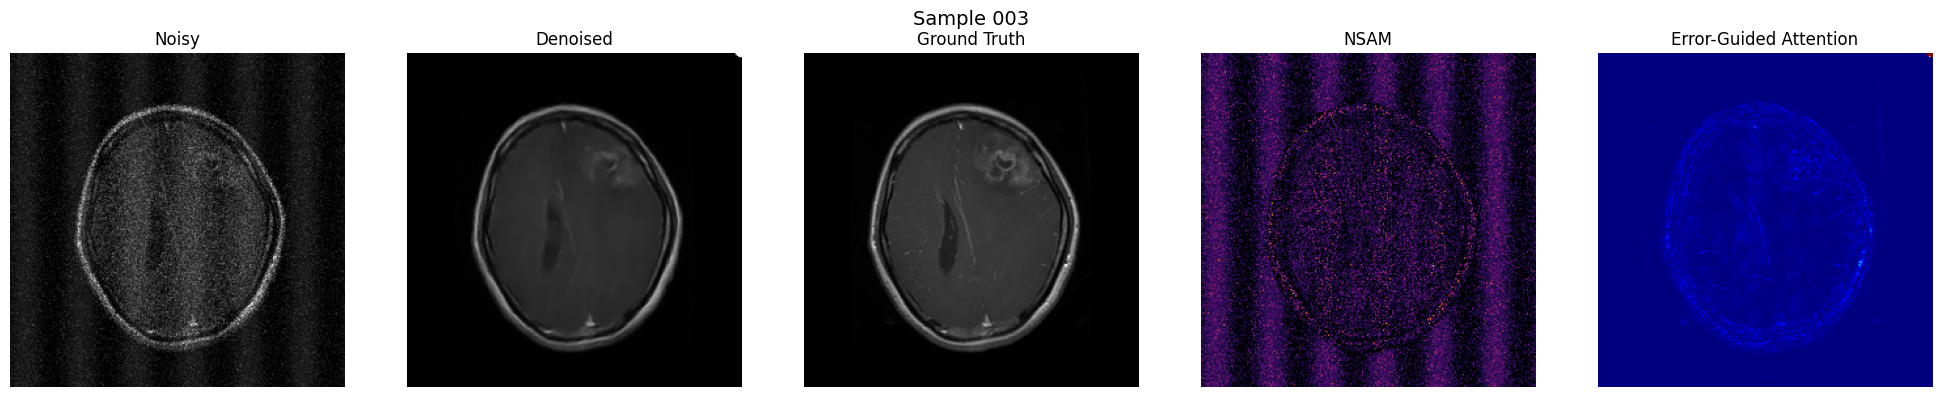

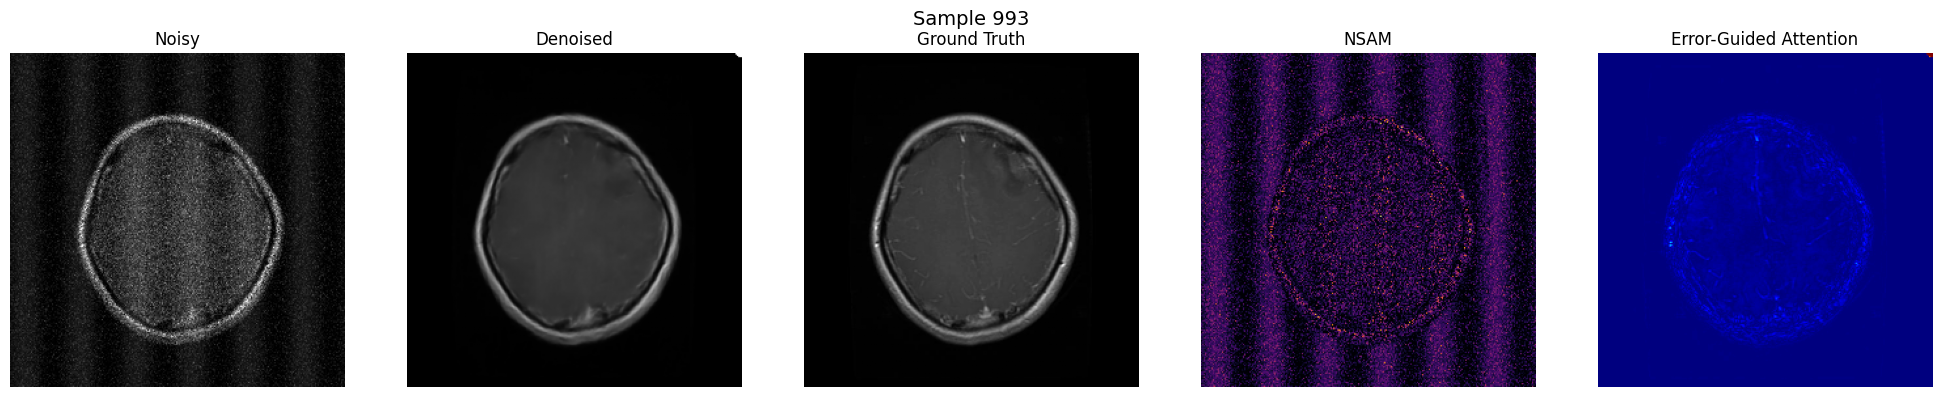

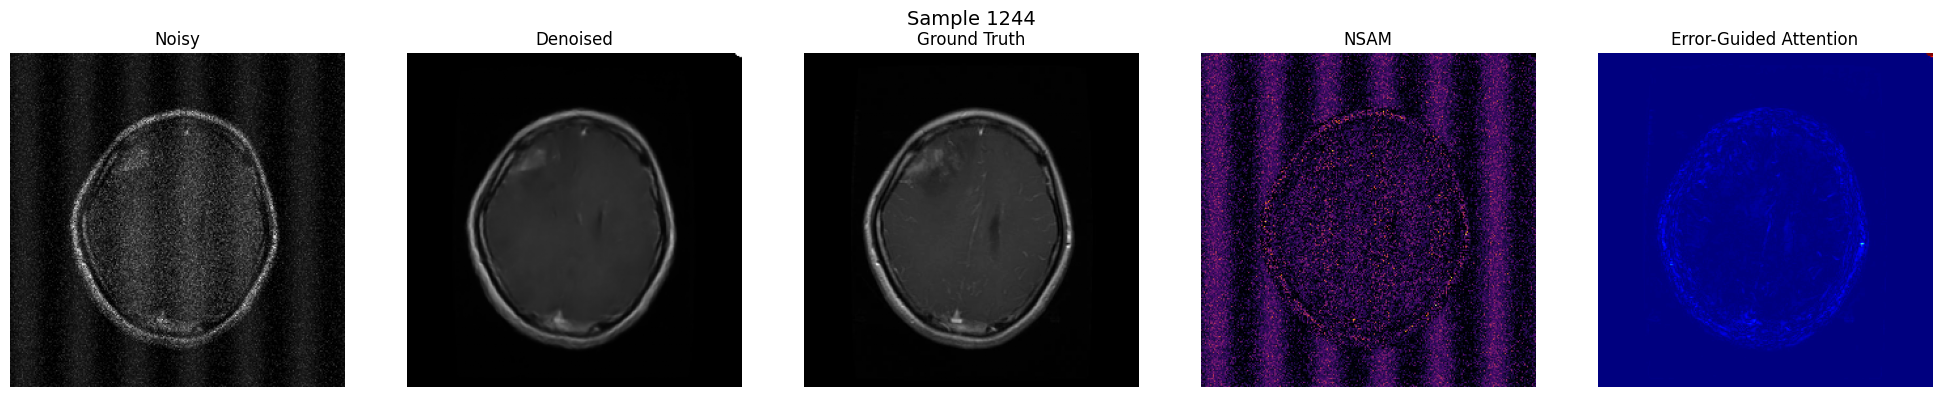

✅ NSAM + EGAM panels saved to: /content/drive/MyDrive/Final RI/inference_all_combined/nsam_egam_panels


In [ ]:
# ===========================
#  Cell: NSAM + Error-Guided Attention Map (Top-3 by SSIM)
# ===========================

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from torchvision.utils import make_grid, save_image

# ---  Paths ---
VIS_DIR = "/content/drive/MyDrive/Final RI/inference_all_combined/nsam_egam_panels"
os.makedirs(VIS_DIR, exist_ok=True)

# ===========================
#  Utility Functions
# ===========================

def compute_nsam(noisy, denoised, clean):
    """
    Noise Suppression Attribution Map (NSAM)
    Highlights regions where noise energy is effectively suppressed
    """
    nsam = np.maximum(
        np.abs(noisy - clean) - np.abs(denoised - clean),
        0
    )
    nsam = nsam / (nsam.max() + 1e-8)
    return nsam


def compute_egam(denoised, clean):
    """
    Error-Guided Attention Map (EGAM)
    Highlights spatial regions with higher reconstruction error
    """
    error = np.abs(clean - denoised)
    egam = (error - error.min()) / (error.max() - error.min() + 1e-8)
    return egam


# ===========================
#  Select Top-3 SSIM Samples
# ===========================

metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "stage1_metrics.csv"))

top3_indices = (
    metrics_df.sort_values("SSIM", ascending=False)
    .head(3)["index"]
    .tolist()
)

print(" Top-3 SSIM samples:", top3_indices)


# ===========================
#  Visualization Loop
# ===========================

count = 0

for i, (noisy_img, clean_img) in enumerate(val_loader):

    if i not in top3_indices:
        continue

    noisy_img = noisy_img.cuda()
    clean_img = clean_img.cuda()

    with torch.no_grad():
        denoised_img, _, _ = G(noisy_img)

    # --- Convert to NumPy ---
    noisy_np    = noisy_img.squeeze().cpu().numpy()
    clean_np    = clean_img.squeeze().cpu().numpy()
    denoised_np = denoised_img.squeeze().cpu().numpy()

    # --- Compute maps ---
    nsam = compute_nsam(noisy_np, denoised_np, clean_np)
    egam = compute_egam(denoised_np, clean_np)

    # ===========================
    #  5-Panel Visualization
    # ===========================

    fig, axs = plt.subplots(1, 5, figsize=(20, 4))

    axs[0].imshow(noisy_np, cmap='gray')
    axs[0].set_title("Noisy")

    axs[1].imshow(denoised_np, cmap='gray')
    axs[1].set_title("Denoised")

    axs[2].imshow(clean_np, cmap='gray')
    axs[2].set_title("Ground Truth")

    axs[3].imshow(nsam, cmap='inferno')
    axs[3].set_title("NSAM")

    axs[4].imshow(egam, cmap='jet')
    axs[4].set_title("Error-Guided Attention")

    for ax in axs:
        ax.axis('off')

    plt.suptitle(f"Sample {i:03d}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # ===========================
    #  Save Panel
    # ===========================

    panel_tensor = torch.tensor(
        np.stack([noisy_np, denoised_np, clean_np, nsam, egam])
    ).unsqueeze(1)

    grid = make_grid(panel_tensor, nrow=5, normalize=True)

    save_image(
        grid,
        os.path.join(VIS_DIR, f"panel_{i:03d}.png")
    )

    count += 1
    if count == 3:
        break


print(f" NSAM + EGAM panels saved to: {VIS_DIR}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ Loaded generator: best_generator_epoch30_ssim0.9168.pt
✈️ Top-3 SSIM samples: [1244, 993, 3]


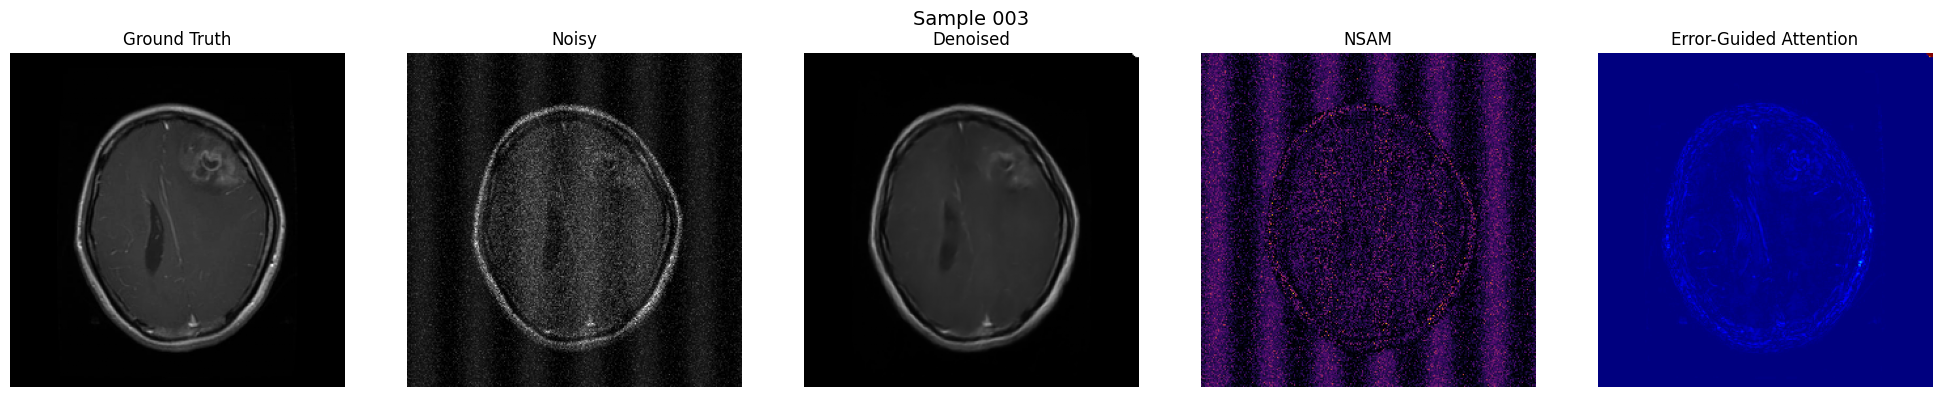

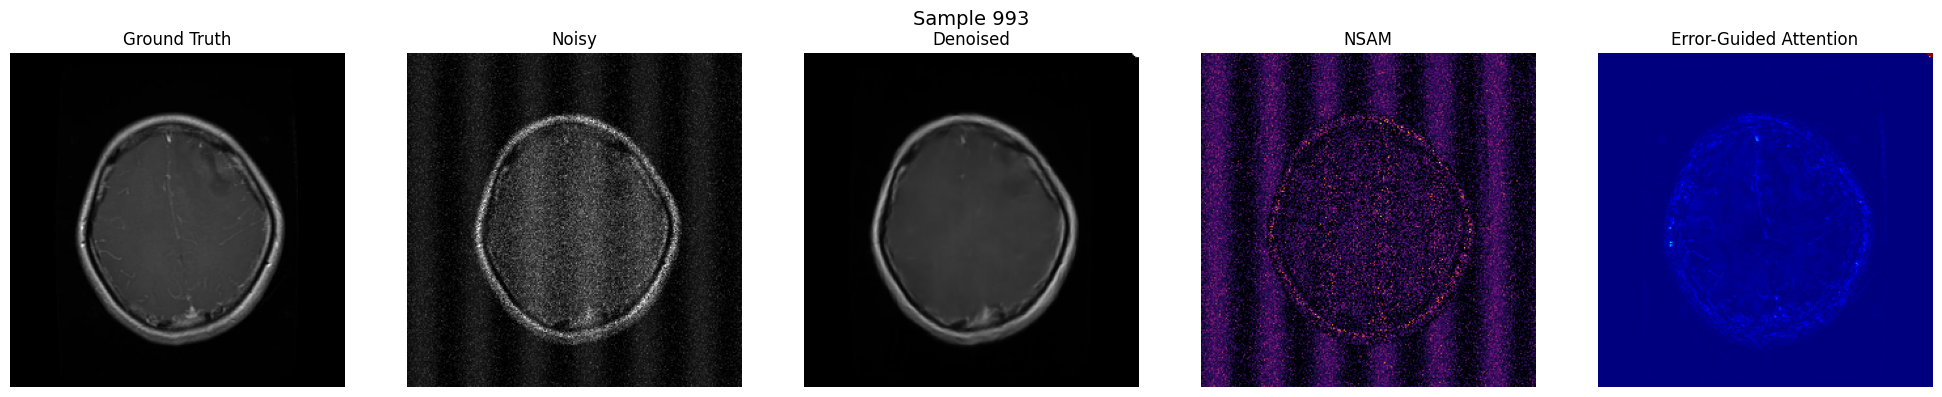

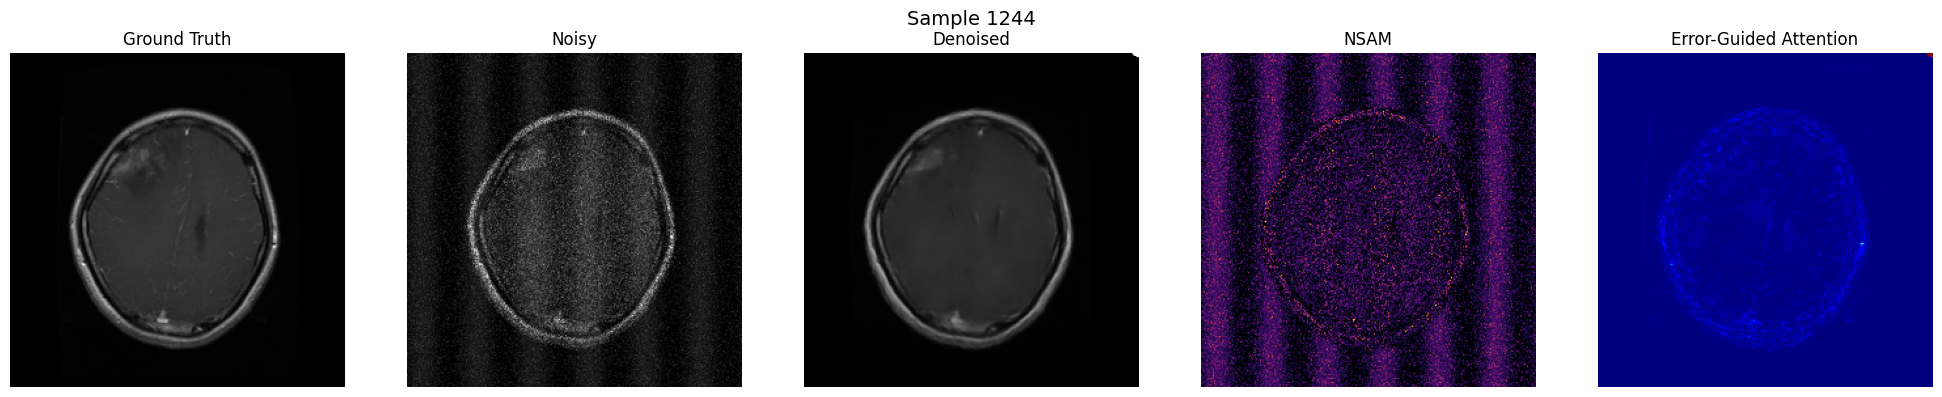

✅ NSAM + EGAM panels saved to: /content/drive/MyDrive/Final RI/inference_all_combined/nsam_egam_panels


In [ ]:
# =========================
# CPU-only version
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import cv2
from glob import glob

# =========================
# --- Settings & Paths ---
# =========================

val_noisy_dir = "/content/drive/MyDrive/Final RI/noisy_glioma/all_combined"
val_clean_dir = "/content/drive/MyDrive/Final RI/glioma"

CHECKPOINT_PATH = "/content/drive/MyDrive/Final RI/checkpoints/all_noise_combined/best_generator_epoch30_ssim0.9168.pt"
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/inference_all_combined"
VIS_DIR = os.path.join(OUTPUT_DIR, "nsam_egam_panels")
os.makedirs(VIS_DIR, exist_ok=True)

# =========================
# --- Dataset & Dataloader ---
# =========================

transform = transforms.Compose([transforms.ToTensor()])

class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        noisy_all = sorted(glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob(os.path.join(clean_dir, "*.*")))

        noisy_dict = {os.path.basename(p): p for p in noisy_all if p.lower().endswith(('.png','.jpg','.jpeg'))}
        clean_dict = {os.path.basename(p): p for p in clean_all if p.lower().endswith(('.png','.jpg','.jpeg'))}

        common_filenames = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        assert common_filenames, " No matching image files found between noisy and clean dirs."

        self.noisy_paths = [noisy_dict[f] for f in common_filenames]
        self.clean_paths = [clean_dict[f] for f in common_filenames]
        self.transform = transform

    def __len__(self):
        return len(self.noisy_paths)

    def __getitem__(self, idx):
        noisy = cv2.imread(self.noisy_paths[idx], cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(self.clean_paths[idx], cv2.IMREAD_GRAYSCALE)
        if noisy is None or clean is None:
            raise ValueError(f"Invalid image: {self.noisy_paths[idx]} or {self.clean_paths[idx]}")

        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32)/255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32)/255.0

        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)

        return noisy, clean

val_dataset = MRIDenoisingDataset(val_noisy_dir, val_clean_dir, transform)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# =========================
# --- UNet Generator ---
# =========================

def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.InstanceNorm2d(out_channels),
        nn.LeakyReLU(0.2, inplace=True)
    )

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
        super().__init__()
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(512*16*16, latent_dim)
        self.fc_logvar = nn.Linear(512*16*16, latent_dim)
        self.fc_decoder = nn.Linear(latent_dim, 512*16*16)
        self.unflatten = nn.Unflatten(1, (512,16,16))

        self.up1 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec1 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = conv_block(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec3 = conv_block(128, 64)
        self.out_conv = nn.Conv2d(64, out_channels, 1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e4_pool = self.pool(e4)

        flat = self.flatten(e4_pool)
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)
        z = self.reparameterize(mu, logvar)
        z = self.unflatten(self.fc_decoder(z))
        z = F.interpolate(z, size=(32,32), mode='bilinear', align_corners=False)

        d1 = self.up1(z)
        d1 = self.dec1(torch.cat([d1, e3], dim=1))
        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d3 = self.up3(d2)
        d3 = self.dec3(torch.cat([d3, e1], dim=1))
        out = torch.sigmoid(self.out_conv(d3))
        return out, mu, logvar

# =========================
# --- Load Model on CPU ---
# =========================

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

G = UNetGenerator()  # <-- CPU version, no .cuda()
G.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=torch.device('cpu')))
G.eval()
print(f" Loaded generator: {os.path.basename(CHECKPOINT_PATH)}")

# =========================
# --- Utility Functions ---
# =========================

def compute_nsam(noisy, denoised, clean):
    nsam = np.maximum(np.abs(noisy-clean) - np.abs(denoised-clean), 0)
    return nsam / (nsam.max() + 1e-8)

def compute_egam(denoised, clean):
    error = np.abs(clean-denoised)
    return (error-error.min()) / (error.max()-error.min() + 1e-8)

# =========================
# --- Select Top-3 SSIM Samples ---
# =========================

metrics_path = os.path.join(OUTPUT_DIR, "stage1_metrics.csv")
if not os.path.exists(metrics_path):
    raise FileNotFoundError(f"Metrics file not found: {metrics_path}")

metrics_df = pd.read_csv(metrics_path)
top3_indices = metrics_df.sort_values("SSIM", ascending=False).head(3)["index"].tolist()
print(" Top-3 SSIM samples:", top3_indices)

# =========================
# --- Visualization Loop ---
# =========================

count = 0
for i, (noisy_img, clean_img) in enumerate(val_loader):
    if i not in top3_indices:
        continue

    # CPU only
    noisy_img = noisy_img
    clean_img = clean_img
    with torch.no_grad():
        denoised_img, _, _ = G(noisy_img)

    noisy_np = noisy_img.squeeze().numpy()
    clean_np = clean_img.squeeze().numpy()
    denoised_np = denoised_img.squeeze().numpy()

    nsam = compute_nsam(noisy_np, denoised_np, clean_np)
    egam = compute_egam(denoised_np, clean_np)

    # --- 5-Panel Plot: GT | Noisy | Denoised | NSAM | EGAM ---
    fig, axs = plt.subplots(1,5, figsize=(20,4))
    axs[0].imshow(clean_np, cmap='gray'); axs[0].set_title("Ground Truth")
    axs[1].imshow(noisy_np, cmap='gray'); axs[1].set_title("Noisy")
    axs[2].imshow(denoised_np, cmap='gray'); axs[2].set_title("Denoised")
    axs[3].imshow(nsam, cmap='inferno'); axs[3].set_title("NSAM")
    axs[4].imshow(egam, cmap='jet'); axs[4].set_title("Error-Guided Attention")
    for ax in axs: ax.axis('off')
    plt.suptitle(f"Sample {i:03d}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- Save Panel ---
    panel_tensor = torch.tensor(np.stack([clean_np, noisy_np, denoised_np, nsam, egam])).unsqueeze(1)
    grid = make_grid(panel_tensor, nrow=5, normalize=True)
    save_image(grid, os.path.join(VIS_DIR, f"panel_{i:03d}.png"))

    count += 1
    if count == 3:
        break

print(f" NSAM + EGAM panels saved to: {VIS_DIR}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from torchvision.utils import make_grid, save_image

# ---  Paths ---
VIS_DIR = "/content/drive/MyDrive/Final RI/inference_all_combined/nsam_egam_panels"
os.makedirs(VIS_DIR, exist_ok=True)

# ===========================
#  Utility Functions
# ===========================

def compute_nsam(noisy, denoised, clean):
    """
    Noise Suppression Attribution Map (NSAM)
    Highlights regions where noise energy is effectively suppressed
    """
    nsam = np.maximum(
        np.abs(noisy - clean) - np.abs(denoised - clean),
        0
    )
    nsam = nsam / (nsam.max() + 1e-8)
    return nsam


def compute_egam(denoised, clean):
    """
    Error-Guided Attention Map (EGAM)
    Highlights spatial regions with higher reconstruction error
    """
    error = np.abs(clean - denoised)
    egam = (error - error.min()) / (error.max() - error.min() + 1e-8)
    return egam


# ===========================
#  Select Top-3 SSIM Samples
# ===========================

metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "stage1_metrics.csv"))

top3_indices = (
    metrics_df.sort_values("SSIM", ascending=False)
    .head(3)["index"]
    .tolist()
)

print(" Top-3 SSIM samples:", top3_indices)


# ===========================
#  Visualization Loop
# ===========================

count = 0

for i, (noisy_img, clean_img) in enumerate(val_loader):

    if i not in top3_indices:
        continue

    noisy_img = noisy_img.cuda()
    clean_img = clean_img.cuda()

    with torch.no_grad():
        denoised_img, _, _ = G(noisy_img)

    # --- Convert to NumPy ---
    noisy_np    = noisy_img.squeeze().cpu().numpy()
    clean_np    = clean_img.squeeze().cpu().numpy()
    denoised_np = denoised_img.squeeze().cpu().numpy()

    # --- Compute maps ---
    nsam = compute_nsam(noisy_np, denoised_np, clean_np)
    egam = compute_egam(denoised_np, clean_np)

    # ===========================
    #  5-Panel Visualization (Reordered)
    # ===========================

    fig, axs = plt.subplots(1, 5, figsize=(20, 4))

    axs[0].imshow(clean_np, cmap='gray')
    axs[0].set_title("Ground Truth")

    axs[1].imshow(noisy_np, cmap='gray')
    axs[1].set_title("Noisy")

    axs[2].imshow(denoised_np, cmap='gray')
    axs[2].set_title("Denoised")

    axs[3].imshow(nsam, cmap='inferno')
    axs[3].set_title("NSAM")

    axs[4].imshow(egam, cmap='jet')
    axs[4].set_title("Error-Guided Attention")

    for ax in axs:
        ax.axis('off')

    plt.suptitle(f"Sample {i:03d}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # ===========================
    #  Save Panel
    # ===========================

    # Reorder tensor as Ground Truth | Noisy | Denoised | NSAM | EGAM
    panel_tensor = torch.tensor(
        np.stack([clean_np, noisy_np, denoised_np, nsam, egam])
    ).unsqueeze(1)

    grid = make_grid(panel_tensor, nrow=5, normalize=True)

    save_image(
        grid,
        os.path.join(VIS_DIR, f"panel_{i:03d}.png")
    )

    count += 1
    if count == 3:
        break


print(f" NSAM + EGAM panels saved to: {VIS_DIR}")

In [ ]:
# ===========================
#  Cell 8: FFT Residual Analysis (Stage 1 Evaluation)
# ===========================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.fftpack import fft2, fftshift
from tqdm import tqdm
import os

# ---  FFT Residual Save Path ---
FFT_DIR = os.path.join(OUTPUT_DIR, "fft_residuals")
os.makedirs(FFT_DIR, exist_ok=True)

# ---  FFT Utility ---
def compute_fft_magnitude(image):
    # Assumes image in [H, W] and float32
    fft = fft2(image)
    fft_shifted = fftshift(fft)
    magnitude = np.abs(fft_shifted)
    magnitude = np.log1p(magnitude)  # for better visualization
    return magnitude

# ---  Visualize FFT Comparison ---
def plot_fft_comparison(noisy, denoised, clean, idx):
    noisy_fft = compute_fft_magnitude(noisy)
    denoised_fft = compute_fft_magnitude(denoised)
    clean_fft = compute_fft_magnitude(clean)
    residual_fft = np.abs(denoised_fft - clean_fft)

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].imshow(noisy_fft, cmap='gray')
    axs[0].set_title("Noisy FFT")

    axs[1].imshow(denoised_fft, cmap='gray')
    axs[1].set_title("Denoised FFT")

    axs[2].imshow(clean_fft, cmap='gray')
    axs[2].set_title("Ground Truth FFT")

    axs[3].imshow(residual_fft, cmap='hot')
    axs[3].set_title("Residual FFT")

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(FFT_DIR, f"fft_residual_{idx:03d}.png"))
    plt.close()

# ---  Apply to All Samples ---
print(f" Generating FFT residual maps...")
for i, (noisy_img, clean_img) in enumerate(tqdm(val_loader)):
    noisy_img = noisy_img.cuda()
    clean_img = clean_img.cuda()
    with torch.no_grad():
        denoised_img, _, _ = G(noisy_img)

    noisy_np = noisy_img.squeeze().cpu().numpy()
    denoised_np = denoised_img.squeeze().cpu().numpy()
    clean_np = clean_img.squeeze().cpu().numpy()

    plot_fft_comparison(noisy_np, denoised_np, clean_np, i)

print(f" FFT visualizations saved to: {FFT_DIR}")


🧠 Generating FFT residual maps...


100%|██████████| 1297/1297 [13:17<00:00,  1.63it/s]

✅ FFT visualizations saved to: /content/drive/MyDrive/Final RI/inference_all_combined/fft_residuals


In [ ]:
# ===========================
#  Cell 9: Clinical Visualization Panels + Summary Tables
# ===========================

import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import os
from torchvision.utils import make_grid

# ---  Set Paths ---
CLINICAL_DIR = os.path.join(OUTPUT_DIR, "clinical_panels")
os.makedirs(CLINICAL_DIR, exist_ok=True)

# ---  Load Metrics CSV ---
df = pd.read_csv(os.path.join(OUTPUT_DIR, "stage1_metrics.csv"))

# ---  Load images (already saved) ---
def load_tensor_image(index):
    img_path = os.path.join(IMG_SAVE_DIR, f"sample_{index:03d}.png")
    img = cv2.imread(img_path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---  Plot Panel with Zoomed ROI ---
def plot_with_zoom(img, index, roi=(80, 80, 40, 40)):
    x, y, w, h = roi
    zoom = img[y:y+h, x:x+w]
    zoom = cv2.resize(zoom, (w*4, h*4), interpolation=cv2.INTER_NEAREST)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img)
    axs[0].add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', lw=2))
    axs[0].set_title(f"Full Panel [{index:03d}]")
    axs[1].imshow(zoom)
    axs[1].set_title(f"Zoomed ROI [{x},{y}]")

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(CLINICAL_DIR, f"panel_{index:03d}.png"))
    plt.close()

# ---  Pick Top Cases by SSIM (Top-3) ---
top_cases = df.sort_values("SSIM", ascending=False).head(3)

print(" Top 3 Cases (Best SSIM):")
print(top_cases)

for idx in list(top_cases["index"]):
    img = load_tensor_image(idx)
    plot_with_zoom(img, idx, roi=(100, 100, 40, 40))  # Adjust ROI if needed

print(f" Saved zoomed panels to: {CLINICAL_DIR}")


🩺 Top 3 Cases (Best SSIM):
      index       PSNR      SSIM
1244   1244  33.403353  0.959037
993     993  32.696305  0.958526
3         3  32.968710  0.956089
✅ Saved zoomed panels to: /content/drive/MyDrive/Final RI/inference_all_combined/clinical_panels


In [ ]:
# ===========================
#  Cell 10: Inline Display — 10 Samples (Noisy | Denoised | GT + Metrics)
# ===========================
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

# ---  Choose Top 10 by SSIM ---
metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "stage1_metrics.csv"))
selected_samples = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()
print(" Selected Top 10 Samples (by SSIM):", selected_samples)

# ---  Display Side-by-Side Panels Inline ---
count = 0
for i, (noisy_img, clean_img) in enumerate(val_loader):
    if i not in selected_samples:
        continue

    noisy_img = noisy_img.cuda()
    clean_img = clean_img.cuda()
    with torch.no_grad():
        denoised_img, _, _ = G(noisy_img)

    noisy_np = noisy_img.squeeze().cpu().numpy()
    denoised_np = denoised_img.squeeze().cpu().numpy()
    clean_np = clean_img.squeeze().cpu().numpy()

    psnr = compute_psnr(clean_np, denoised_np, data_range=1.0)
    ssim = compute_ssim(clean_np, denoised_np, data_range=1.0)

    # ---  Display in Notebook ---
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].imshow(noisy_np, cmap='gray')
    axs[0].set_title(f" Noisy Input")

    axs[1].imshow(denoised_np, cmap='gray')
    axs[1].set_title(f" Denoised\nPSNR: {psnr:.2f} dB\nSSIM: {ssim:.4f}")

    axs[2].imshow(clean_np, cmap='gray')
    axs[2].set_title(f" Ground Truth")

    for ax in axs:
        ax.axis('off')

    plt.suptitle(f" Sample {i:03d}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

    count += 1
    if count == 10:
        break


Output hidden; open in https://colab.research.google.com to view.

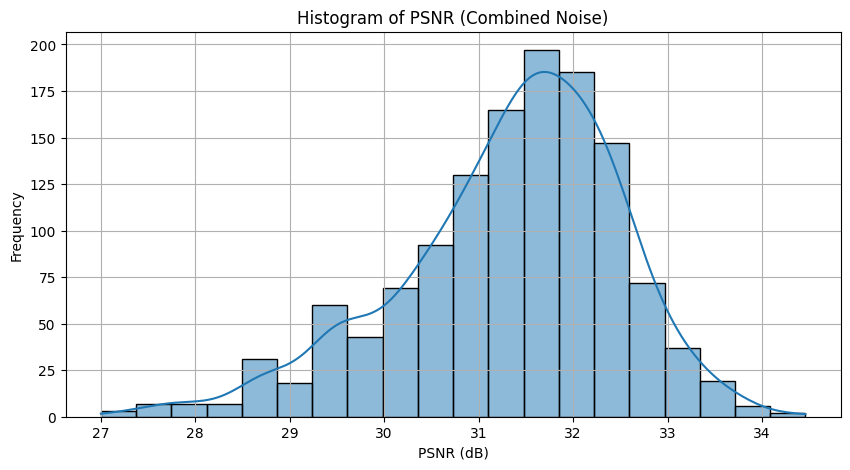

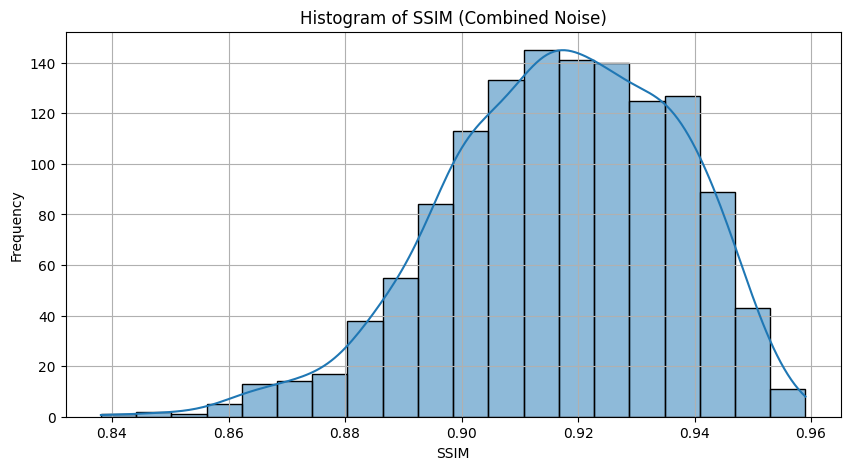

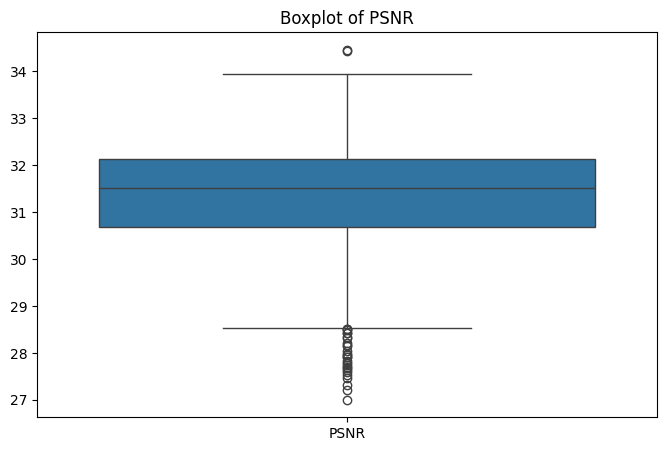

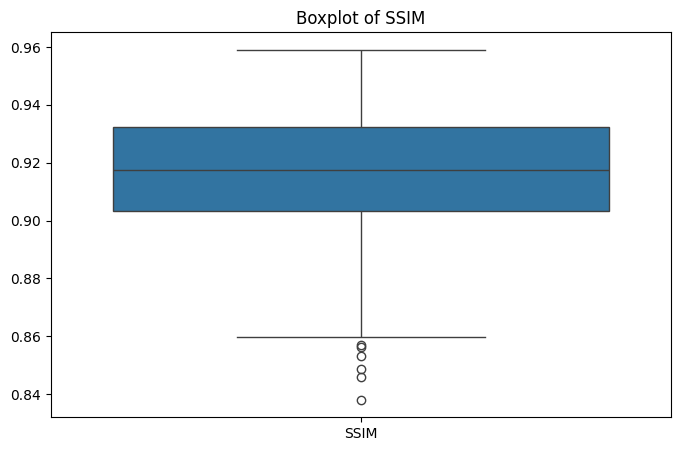

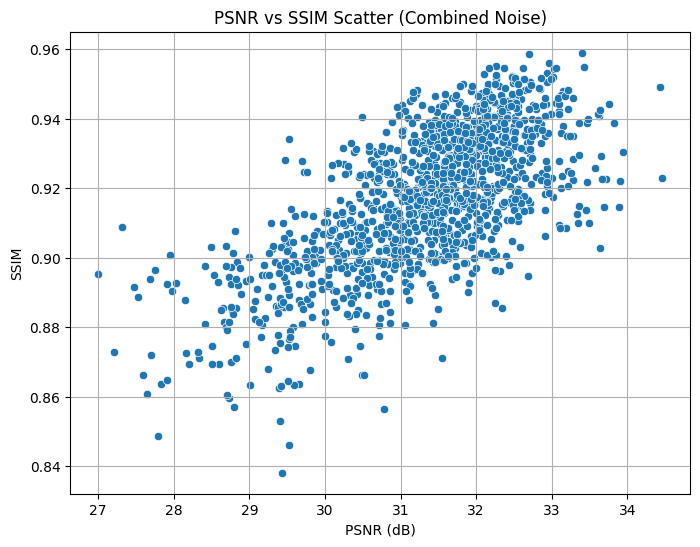

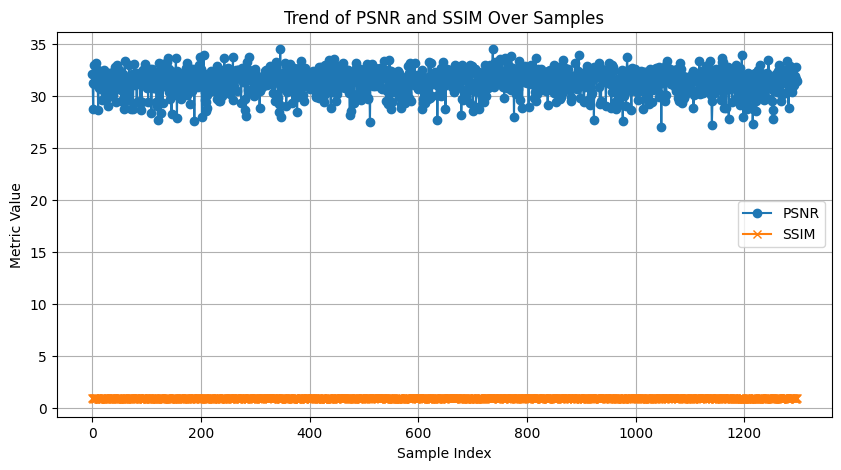

📊 Combined Noise Metrics Summary:
   → Avg PSNR: 31.32 dB
   → Avg SSIM: 0.9168
📁 All plots saved to: /content/drive/MyDrive/Final RI/inference_all_combined/plots


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---  Set Paths ---
CSV_PATH = "/content/drive/MyDrive/Final RI/inference_all_combined/stage1_metrics.csv"
PLOT_SAVE_DIR = "/content/drive/MyDrive/Final RI/inference_all_combined/plots"
os.makedirs(PLOT_SAVE_DIR, exist_ok=True)

# ---  Load Metrics ---
df = pd.read_csv(CSV_PATH)

# ---  1. Histogram of PSNR and SSIM ---
plt.figure(figsize=(10, 5))
sns.histplot(df["PSNR"], bins=20, kde=True)
plt.title("Histogram of PSNR (Combined Noise)")
plt.xlabel("PSNR (dB)")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig(os.path.join(PLOT_SAVE_DIR, "hist_psnr.png"))
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df["SSIM"], bins=20, kde=True)
plt.title("Histogram of SSIM (Combined Noise)")
plt.xlabel("SSIM")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig(os.path.join(PLOT_SAVE_DIR, "hist_ssim.png"))
plt.show()

# ---  2. Boxplot for PSNR and SSIM ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["PSNR"]])
plt.title("Boxplot of PSNR")
plt.savefig(os.path.join(PLOT_SAVE_DIR, "boxplot_psnr.png"))
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["SSIM"]])
plt.title("Boxplot of SSIM")
plt.savefig(os.path.join(PLOT_SAVE_DIR, "boxplot_ssim.png"))
plt.show()

# ---  3. PSNR vs SSIM Scatter Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PSNR", y="SSIM", data=df)
plt.title("PSNR vs SSIM Scatter (Combined Noise)")
plt.xlabel("PSNR (dB)")
plt.ylabel("SSIM")
plt.grid(True)
plt.savefig(os.path.join(PLOT_SAVE_DIR, "scatter_psnr_ssim.png"))
plt.show()

# ---  4. Trend Plot (Index vs PSNR/SSIM) ---
plt.figure(figsize=(10, 5))
plt.plot(df["index"], df["PSNR"], label="PSNR", marker='o')
plt.plot(df["index"], df["SSIM"], label="SSIM", marker='x')
plt.xlabel("Sample Index")
plt.ylabel("Metric Value")
plt.title("Trend of PSNR and SSIM Over Samples")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(PLOT_SAVE_DIR, "trend_psnr_ssim.png"))
plt.show()

# ---  5. Summary Printout ---
avg_psnr = df["PSNR"].mean()
avg_ssim = df["SSIM"].mean()

print(f" Combined Noise Metrics Summary:")
print(f"   → Avg PSNR: {avg_psnr:.2f} dB")
print(f"   → Avg SSIM: {avg_ssim:.4f}")
print(f" All plots saved to: {PLOT_SAVE_DIR}")


In [ ]:
# ===========================
# Cell 10: Inline Display — Top 10 Samples
# Order: Ground Truth | Noisy | Denoised + Metrics
# ===========================

import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

# ---  Set Paths (Added from Cell 7) ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/inference_all_combined"

# =========================
# Re-defining dependencies for val_loader
# =========================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2 # Already imported but ensuring visibility
from glob import glob # Required for MRIDenoisingDataset

# ---  Normalize & Transform (from Cell 2) ---
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [C, H, W] float32 in [0, 1]
])

# ---  Robust Dataset Class (from Cell 2) ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        # Corrected pattern to "*.*" (removing the trailing space)
        noisy_all = sorted(glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob(os.path.join(clean_dir, "*.*")))

        # Build dicts of filename → path
        noisy_dict = {os.path.basename(p): p for p in noisy_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}
        clean_dict = {os.path.basename(p): p for p in clean_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

        # Match only common filenames
        common_filenames = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        assert common_filenames, " No matching image files found between noisy and clean dirs."

        # Build matched path lists
        self.noisy_paths = [noisy_dict[f] for f in common_filenames]
        self.clean_paths = [clean_dict[f] for f in common_filenames]
        self.transform = transform

    def __len__(self):
        return len(self.noisy_paths)

    def __getitem__(self, idx):
        noisy_path = self.noisy_paths[idx]
        clean_path = self.clean_paths[idx]

        noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)

        if noisy is None or clean is None:
            raise ValueError(f"Invalid image: {noisy_path} or {clean_path}")

        # Resize and normalize to [0, 1]
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0

        # Apply transform
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)

        return noisy, clean

# ---  Set Paths for Training/Validation (All Combined Noise) (from Cell 2) ---
val_noisy_dir   = "/content/drive/MyDrive/Final RI/noisy_glioma/all_combined"
val_clean_dir   = "/content/drive/MyDrive/Final RI/glioma"

# ---  Create Dataset Objects (from Cell 2) ---
val_dataset   = MRIDenoisingDataset(val_noisy_dir, val_clean_dir, transform)

# ---  Dataloaders (from Cell 6) ---
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)

# =========================
# Model definition and loading (from Cell 3 and 7)
# =========================

import torch.nn as nn
import torch.nn.functional as F

# ---  Conv Block with InstanceNorm ---
def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.InstanceNorm2d(out_channels),
        nn.LeakyReLU(0.2, inplace=True)
    )

# ---  VAE + U-Net Generator (No MoE, No Transformer)
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
        super(UNetGenerator, self).__init__()

        # --- Encoder ---
        self.enc1 = conv_block(in_channels, 64)       # -> [B, 64, 256, 256]
        self.enc2 = conv_block(64, 128)               # -> [B, 128, 128, 128]
        self.enc3 = conv_block(128, 256)              # -> [B, 256, 64, 64]
        self.enc4 = conv_block(256, 512)              # -> [B, 512, 32, 32]
        self.pool = nn.MaxPool2d(2)

        # --- VAE Latent Bottleneck ---
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_decoder = nn.Linear(latent_dim, 512 * 16 * 16)
        self.unflatten = nn.Unflatten(1, (512, 16, 16))

        # --- Decoder (U-Net with skip connections) ---
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = conv_block(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # --- Encode ---
        e1 = self.enc1(x)                # [B, 64, 256, 256]
        e2 = self.enc2(self.pool(e1))    # [B, 128, 128, 128]
        e3 = self.enc3(self.pool(e2))    # [B, 256, 64, 64]
        e4 = self.enc4(self.pool(e3))    # [B, 512, 32, 32]
        e4_pool = self.pool(e4)          # [B, 512, 16, 16]

        # --- VAE bottleneck ---
        flat = self.flatten(e4_pool)     # [B, 512*16*16]
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)
        z = self.reparameterize(mu, logvar)
        z = self.unflatten(self.fc_decoder(z))        # [B, 512, 16, 16]
        z = F.interpolate(z, size=(32, 32), mode='bilinear', align_corners=False)

        # --- Decode ---
        d1 = self.up1(z)                         # [B, 256, 64, 64]
        d1 = self.dec1(torch.cat([d1, e3], dim=1))

        d2 = self.up2(d1)                        # [B, 128, 128, 128]
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d3 = self.up3(d2)                        # [B, 64, 256, 256]
        d3 = self.dec3(torch.cat([d3, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d3))   # [B, 1, 256, 256]
        return out, mu, logvar

# ---  Load Best Generator ---
# Adjusted SAVE_PATH to point to the subdirectory where the combined noise models are likely stored.
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/all_noise_combined"

# Debugging: List directory contents
print(f"Contents of {SAVE_PATH}: {os.listdir(SAVE_PATH)}")

model_paths = glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt"))

if not model_paths:
    raise FileNotFoundError(f"No generator models found in {SAVE_PATH} matching 'best_generator_epoch*.pt'. Please ensure training completed successfully in Cell 6 and that the path is correct.")

best_model_path = max(model_paths, key=os.path.getctime)

G = UNetGenerator().cuda()
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator: {os.path.basename(best_model_path)}")

# =========================
# Select Top 10 by SSIM
# =========================
metrics_path = os.path.join(OUTPUT_DIR, "stage1_metrics.csv")

if not os.path.exists(metrics_path):
    raise FileNotFoundError(f"Metrics file not found: {metrics_path}")

metrics_df = pd.read_csv(metrics_path)
selected_samples = (
    metrics_df.sort_values("SSIM", ascending=False)
    .head(10)["index"]
    .tolist()
)

print("Selected Top 10 Samples (by SSIM):", selected_samples)

# =========================
# Display Side-by-Side Panels
# =========================
count = 0

for i, (noisy_img, clean_img) in enumerate(val_loader):

    if i not in selected_samples:
        continue

    # Move to GPU safely
    noisy_img = noisy_img.cuda(non_blocking=True)
    clean_img = clean_img.cuda(non_blocking=True)

    # Model inference
    with torch.no_grad():
        denoised_img, _, _ = G(noisy_img)

    # Convert to numpy
    noisy_np = noisy_img.squeeze().cpu().numpy()
    denoised_np = denoised_img.squeeze().cpu().numpy()
    clean_np = clean_img.squeeze().cpu().numpy()

    # Compute metrics
    psnr = compute_psnr(clean_np, denoised_np, data_range=1.0)
    ssim = compute_ssim(clean_np, denoised_np, data_range=1.0)

    # =========================
    # Visualization
    # Order: Ground Truth | Noisy | Denoised
    # =========================
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # Ground Truth (first)
    axs[0].imshow(clean_np, cmap="gray")
    axs[0].set_title("Ground Truth")
    axs[0].axis("off")

    # Noisy Input (second)
    axs[1].imshow(noisy_np, cmap="gray")
    axs[1].set_title("Noisy Input")
    axs[1].axis("off")

    # Denoised Output (third)
    axs[2].imshow(denoised_np, cmap="gray")
    axs[2].set_title(
        f"Denoised Output\nPSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}"
    )
    axs[2].axis("off")

    plt.suptitle(f"Sample {i:03d}", fontsize=14)
    plt.tight_layout()
    plt.show()

    count += 1
    if count == 10:
        break

Output hidden; open in https://colab.research.google.com to view.